# Meta Heroes base on M6 World Championship Tournament

## 1 Project Introduction

Among the mobile legends player, M series tournaments have been the most interesting and watched tournament throught out the years, hyping for their countries representative team and getting excited about which team will be the winner and get the trophy. For me, although we can have insight about which mlbb heroes have more benefit compare to other heroes from the social media, I believe we can analyze about that by ourselves from the hero picked pattern in the mlbb's biggest tournament. 

In this project, I will aim to make analysis about the meta hero that the pro team are mainly using in the tournament for the win. Even further, i want to explore about if the draft is one of the factor that decide the match minner and lastly the most interesting debate which is whether Phillipine teams are the strongest in this tournament or not.

## 1.1 Aim and Objectives

The overall aim of this project is to prove some of the trending debate and assumption among the players with statistics and existing data. People had been arguing these things more than a few years and nobody had been proven with facts yet. So, this would be an interesting project for me and who knows, I could come up with some useful information that I can share back to the public. (example: the heroes that the professional players had been abusing in tournament which could help in increasing the chance of winning the game if normal people like us use in our own matches).

For this project, I am aiming for 3 objectives and I will list base on the priority and difficulty.

1. Meta Heroes acquire from the tournament
2. Relation between hero draft and win rate
3. Whether Phillipine teams are no match for other countries and what is behind their victory in this tournament series

## 1.2 Project Background

Out of everything from Mobile Legend game, why did I choose to find the meta heroes, why would I specifically reflect data only on M6 tournament when I can gather from other tournament and daily public games that normal people are playing, why is Liquipedia great website for my project aim and objectives?

First of all, I would like to explain what is the term meta and how it is related to my research. Usually, the game developer try to find improvement in the game to attract more people to play their game. They need to make adjustment to the feature and this include adjusting the game characters and their ability. They need to adjust everything smoothly and consistently, but as a human, they also make mistake by accidentally making some of the heroes more powerful compare to other. Usually, it would take like a month for the adjustment to be made and to be released so we always curious to find out which of the heroes are overpower before the next adjustment come out. In gaming term this is known as meta and knowing the meta can bring you to more victories.

The M6 is the recent biggest Mobile Legend game tournament from M series and it would be quite useless to do an analysis about meta hero from earlier M series tournament. Apart from that, every teams in this tournament would try not to make any mistake to be champion as this is the biggest tournament compare to other tournaments and normal game so data from this tournament will be the most accurate one for my project.

A brief about Liquipedia would be that it is a website for gathering games related data especially the data for pro team in gaming field. It is similar to wikipedia which share knowledge but Liquipedia is more of the game news and knowledge. In Liquipedia, they already have a statistic table about the heroes throughout the tournament which is very useful for my project and matched with what I was looking for.

## 2 Data

The data that I will be using is from 3 stages of the tournament. 

There is wildcard stage which is giving a chance to some of the regions around the world. Because some of the regions are a bit weak, I wouldn't include those data to reduce inaccuarcy.

Another one is swiss stage which is the stage that decide which 8 teams can proceed to knockout stage. This stage is a bit similar to round of robin where they still got a chance even after a few lose.

The last one is knockout stage which determine the winner of the tournament. This is the most important stage so every team tried their best here and the data collected from this stage will be the most accurate data.

In my project I will use the data from swiss stage, knockout stage and lastly overall stage which is the combine data of those 3 stages.

## 2.1  Acquiring Data

For these objectives, I will need some stats and data about the hero usage in m6 tournament, some of the match detail in m6 tournament and all the data throughout the M series for last objective. I had tried to find the dataset regarding the analysis I want to do in Kaggle but I couldn't find any relevant dataset so I decided to scrape the data. Liquipedia is one of the great website when it come to finding the game detail and the data. 

I aimed to scrape the data from: https://liquipedia.net/mobilelegends/M6_World_Championship/Knockout_Stage and https://liquipedia.net/mobilelegends/M6_World_Championship/Statistics for my objective one and two but I only managed to do for their Statistics page as the Knockout_Stage structure is a bit complex for me to scrape the data I want.

## 2.2 Scraping Data

In [1]:
import requests
from bs4 import BeautifulSoup
import csv

These are the libraries that I have import. I have imported requests and BeautifulSoup for scraping the data from Liquipedia page and csv for creating a new csv file with the desired data

In [2]:
# Function to scrape data from a specific URL
def scrape_hero_stats(url, output_file):
    # Fetch the page content
    response = requests.get(url)
    soup = BeautifulSoup(response.content, 'html.parser')

    # Locate the statistics table
    table = soup.find('table', {'class': 'wikitable'})

    # Extract the rows of the table
    rows = table.find_all('tr')

def scrape_hero_stats is a main function for doing the scrape. It has two argument; the first argument is for taking the web page url to the function and the second argument is for transforming to csv file. 

requests.get() is to send a GET request to the URL to fetch the data. BeautifulSoup() is for parsing the HTML content into a format that is easier to manipulate. 

soup.find('table', {'class': 'wikitable'}) is for finding the segment in HTML structure where class is wikitable. 

Under that class, we gonna get every row from the table so I assign table.find_all('tr').

In [3]:
    # Define the headers and corresponding column indexes
    custom_headers = [
        "Hero", "Total Picks", "Total Wins", "Total Losses", "Win Rate", "Pick Rate", "Total Bans", "Ban Rate", "Total Picks and Bans", "Total Picks and Bans Rate"
    ]
    require_columns = [1, 2, 3, 4, 5, 6, 15, 16, 17, 18]

    # Prepare the data for the CSV
    data = []

In [4]:
    # Process table rows skipping the header
    for row in rows[1:]:
        cells = row.find_all('td')
        if len(cells) < max(require_columns):
            continue

        # Extract data
        filtered_row = [cells[index].text.strip() for index in require_columns]
        data.append(filtered_row)

NameError: name 'rows' is not defined

I used for looping to get the all the rows and start from 1 to skip the table header. From that we take the data column by column usind 'td' attribute. 

The condition statement is to skip in case there are rows with inssufficient columns.

filtered_row is to ensure getting only the column I want.

In [21]:
    # Write to the CSV file
    with open(output_file, 'w', newline='', encoding='utf-8') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(custom_headers)
        writer.writerows(data)

NameError: name 'output_file' is not defined

This is for creating the csv file, writing the column header by passing the custom_headers argument and the data collected through going the URLs.

In [ ]:
# URLs of the stats
swiss_url = 'https://liquipedia.net/mobilelegends/M6_World_Championship/Statistics/Swiss_Stage'
knockout_url = 'https://liquipedia.net/mobilelegends/M6_World_Championship/Statistics/Knockout_Stage'
overall_url = 'https://liquipedia.net/mobilelegends/M6_World_Championship/Statistics'

These are the URLs of the page that I had gathered my data for this project.

In [ ]:
# Output file names
swiss_output = 'Swiss_Stage_Hero_Stats.csv'
knockout_output = 'Knockout_Stage_Hero_Stats.csv'
overall_output = 'Overall_Hero_Stats.csv'

In [ ]:
# Scraping the data 
scrape_hero_stats(swiss_url, swiss_output)
scrape_hero_stats(knockout_url, knockout_output)
scrape_hero_stats(overall_url, overall_output)

By passing these variables as argument to the function, i can acquire the data from my desired web page into the csv file that i want to create.

## 2.3 Data Cleaning

In [35]:
# Data Cleaning Code
import pandas as pd

# Function to clean and process the dataset
def clean_dataset(file_name):
    # Load the dataset
    df = pd.read_csv(file_name)

    # Clean and convert percentage columns
    percentage_columns = ['Win Rate', 'Pick Rate', 'Ban Rate', 'Total Picks and Bans Rate']
    for td in percentage_columns:
        df[td] = pd.to_numeric(df[td].str.rstrip('%'), errors='coerce') / 100

    # Handle missing 'Win Rate' values by directly modifying the original DataFrame
    if 'Win Rate' in df:
        df['Win Rate'] = df['Win Rate'].fillna(0)

    # Filter columns
    preferred_columns = [
        "Hero", "Total Picks", "Win Rate", "Pick Rate", "Total Bans", "Ban Rate", "Total Picks and Bans", "Total Picks and Bans Rate"
    ]
    return df[preferred_columns]

I had changed the percent value into number so it will be easier for me to manipulate further. 

The error handling, errors='coerce' help me ensure there is no invalid entries. Although my dataset is quite small and easier to fix, this will help me in handling the data if I want to go further like comparing hero usage stats from M1 to M6 tournaments. 

In the original Data, there is no win rate for those hero with 0 picks so the data are null and this will be troublesome to manipulate them so I change them to 0 as a digit just in case.

Then, I had filtered the table as I won't need all the column that I had fetched.

## 2.4 Data Filtering

In [36]:
# Function to get the top 25 heroes from a specific stage based on Total Picks and Bans Rate
def get_top_25_heroes(df):
    return df.sort_values(by="Total Picks and Bans Rate", ascending=False).head(25)['Hero'].tolist()

# Function to filter and reorder dataset based on top 25 heroes
def filter_reorder(df, top_heroes):
    filtered_df = df[df['Hero'].isin(top_heroes)].copy()
    return filtered_df.set_index('Hero').reindex(top_heroes).reset_index()

# File paths
overall_file = "Overall_Hero_Stats.csv"
swiss_stage_file = "Swiss_Stage_Hero_Stats.csv"
knockout_stage_file = "Knockout_Stage_Hero_Stats.csv"

# Clean datasets
overall_cleaned = clean_dataset(overall_file)
swiss_cleaned = clean_dataset(swiss_stage_file)
knockout_cleaned = clean_dataset(knockout_stage_file)

# Get top 25 heroes based on the Knockout Stage
top_25_knockout_heroes = get_top_25_heroes(knockout_cleaned)

# Filter and reorder datasets based on the top 25 heroes
overall_filtered = filter_reorder(overall_cleaned, top_25_knockout_heroes)
swiss_filtered = filter_reorder(swiss_cleaned, top_25_knockout_heroes)
knockout_filtered = filter_reorder(knockout_cleaned, top_25_knockout_heroes)

The index number after filtering is a bit messy and random which make hard for me to look so I change the index number to be 1 to 25 for top 25.

The other line of codes are just assigning variable for easier access in plotting.

## 2.5 Data Display

In [41]:
# Function to process and display the top 25 heroes
def display_top_heroes(cleaned_df, stage_name):
    # Sort by Total Picks and Bans Rate and keep the top 25 heroes
    sorted_df = cleaned_df.sort_values(by="Total Picks and Bans Rate", ascending=False)
    top_heroes_df = sorted_df.head(25)
    
    # Reset the index and start it from 1
    top_heroes_df.reset_index(drop=True, inplace=True)
    top_heroes_df.index += 1  # Adjust index to start from 1
    
    # Display the table
    print(f"{stage_name} Data:")
    display(top_heroes_df)

I had sorted the table based on total pick and bans from ascending to decending because that column will be the main column I will focus during analysis.

Reducing to 25 rows as I wouldn't need every rows to give conclusion about meta heroes and I will just aim to get 5 to 10 heroes after analysis. 

After sorting and filtering, the index become messy so I reset the index and add 1 to it since it starts from 0.

In [42]:
display_top_heroes(overall_filtered, "Overall Stage")

Overall Stage Data:


,Hero,Total Picks,Win Rate,Pick Rate,Total Bans,Ban Rate,Total Picks and Bans,Total Picks and Bans Rate
1,Zhuxin,24,0.4583,0.1791,107,0.7985,131,0.9776
2,Hilda,44,0.6136,0.3284,86,0.6418,130,0.9701
3,Bruno,72,0.5556,0.5373,56,0.4179,128,0.9552
4,Fanny,3,0.3333,0.0224,123,0.9179,126,0.9403
5,Suyou,93,0.5591,0.6940,30,0.2239,123,0.9179
6,Chou,68,0.5882,0.5075,55,0.4104,123,0.9179
7,Hylos,71,0.3803,0.5299,39,0.2910,110,0.8209
8,Yve,33,0.7273,0.2463,76,0.5672,109,0.8134
9,Mathilda,19,0.5263,0.1418,77,0.5746,96,0.7164
10,Joy,59,0.5254,0.4403,34,0.2537,93,0.6940


In [43]:
display_top_heroes(swiss_filtered, "Swiss Stage")

Swiss Stage Data:


,Hero,Total Picks,Win Rate,Pick Rate,Total Bans,Ban Rate,Total Picks and Bans,Total Picks and Bans Rate
1,Bruno,28,0.6429,0.5385,24,0.4615,52,1.0000
2,Zhuxin,14,0.5714,0.2692,36,0.6923,50,0.9615
3,Hilda,16,0.6250,0.3077,34,0.6538,50,0.9615
4,Hylos,31,0.4516,0.5962,18,0.3462,49,0.9423
5,Chou,29,0.6207,0.5577,19,0.3654,48,0.9231
6,Fanny,2,0.5000,0.0385,45,0.8654,47,0.9038
7,Suyou,34,0.5882,0.6538,11,0.2115,45,0.8654
8,Yve,9,0.6667,0.1731,34,0.6538,43,0.8269
9,Joy,29,0.4138,0.5577,10,0.1923,39,0.7500
10,Mathilda,5,0.6000,0.0962,34,0.6538,39,0.7500


In [44]:
display_top_heroes(knockout_filtered, "Knockout Stage")

Knockout Stage Data:


,Hero,Total Picks,Win Rate,Pick Rate,Total Bans,Ban Rate,Total Picks and Bans,Total Picks and Bans Rate
1,Fanny,0,0.0000,0.0000,49,1.0000,49,1.0000
2,Bruno,24,0.5833,0.4898,25,0.5102,49,1.0000
3,Zhuxin,7,0.2857,0.1429,41,0.8367,48,0.9796
4,Suyou,35,0.4857,0.7143,12,0.2449,47,0.9592
5,Hilda,22,0.5455,0.4490,25,0.5102,47,0.9592
6,Joy,26,0.6923,0.5306,20,0.4082,46,0.9388
7,Chou,19,0.4211,0.3878,23,0.4694,42,0.8571
8,Granger,26,0.5385,0.5306,15,0.3061,41,0.8367
9,Mathilda,9,0.5556,0.1837,28,0.5714,37,0.7551
10,Yve,19,0.7895,0.3878,14,0.2857,33,0.6735


## 2.6 Ethical Use of Data

By the Liquipedia Web Site Terms and Condition of Use 2. Use License a, "Permission is granted to use the materials (information or software) on Team Liquid's web site for personal, non-commercial transitory viewing only", we are allowed to used their data as it is for self analysis purpose and we will not harm their website nor their content.

The use of the data from the website is strictly for non-commercial, educational, and analytical purposes to gain insights into hero statistics.

I also acknowledge their work for this data and I give credit for part of the work.

For more of their term, please visit the link: https://tl.net/tou/

## 2.7 Consideration of Alternative Datasets

### Liquipedia

Strength:

Liquipedia focuses specifically on professional esports tournaments, providing detailed data on hero picks, bans, win rates, and other statistics for the M6 World Championship.

The site refresh it content frequently by the help esports enthusiasts, ensuring the data reflects the most recent tournaments and matches.

Weakness:

Being managed by a community, there is a risk of inaccuracies or inconsistencies in data entry.

The page focus is mainly on pro scene so it would be hard to enlarge the scope further.

### Kaggle

Strength:

Kaggle datasets are often preprocessed and come with clear documentation, making them easy to integrate into analysis pipelines.

Kaggle offers various datasets on gaming statistics.

Weakness:

Some of the fields are limited, which make it hard to find the desired dataset.

Some Kaggle datasets may not be updated frequently, reducing their relevance for analyzing.

### Official MLBB Statistics

Strength:

Official statistics from Mobile Legends: Bang Bang (MLBB) developers are likely to be highly accurate and comprehensive.

Official sources may provide insights beyond hero statistics, such as player performance, trend among different region, and match-specific details.

Weakness:

Official data may not be eaisly given access to the public or may require special permissions to access.

Usage of official data may come with strict licensing or copyright limitations.

## 3 Plot

In [71]:
import matplotlib.pyplot as plt
import numpy as np

# Function to plot grouped bar charts
def plot_total_picks_and_bans(overall_df, swiss_stage_df, knockout_stage_df):
    heroes = knockout_stage_df['Hero']

    # Prepare data for each stage
    overall_values = [
        overall_df.loc[overall_df['Hero'] == hero, 'Total Picks and Bans Rate'].values[0] if hero in overall_df['Hero'].values else 0 for hero in heroes
    ]
    swiss_values = [
        swiss_stage_df.loc[swiss_stage_df['Hero'] == hero, 'Total Picks and Bans Rate'].values[0] if hero in swiss_stage_df['Hero'].values else 0 for hero in heroes
    ]
    knockout_values = [
        knockout_stage_df.loc[knockout_stage_df['Hero'] == hero, 'Total Picks and Bans Rate'].values[0] if hero in knockout_stage_df['Hero'].values else 0 for hero in heroes
    ]

    # Bar chart settings
    x = np.arange(len(heroes))
    bar_width = 0.25

    # Plot
    plt.figure(figsize=(16, 8))
    plt.bar(x - bar_width, overall_values, width=bar_width, label='Overall', color='#7eb0d5')
    plt.bar(x, swiss_values, width=bar_width, label='Swiss', color='#fd7f6f')
    plt.bar(x + bar_width, knockout_values, width=bar_width, label='Knockout', color='#b2e061')
    plt.xticks(x, heroes, rotation=45, ha='right')
    plt.xlabel("Heroes")
    plt.ylabel("Total Picks and Bans Rate")
    plt.title("Total Picks and Bans Rate for Top 25 Heroes Across Stages")
    plt.legend()
    plt.tight_layout()
    plt.show()

## 3.1 Total Picks and Bans Comparison for all the stages

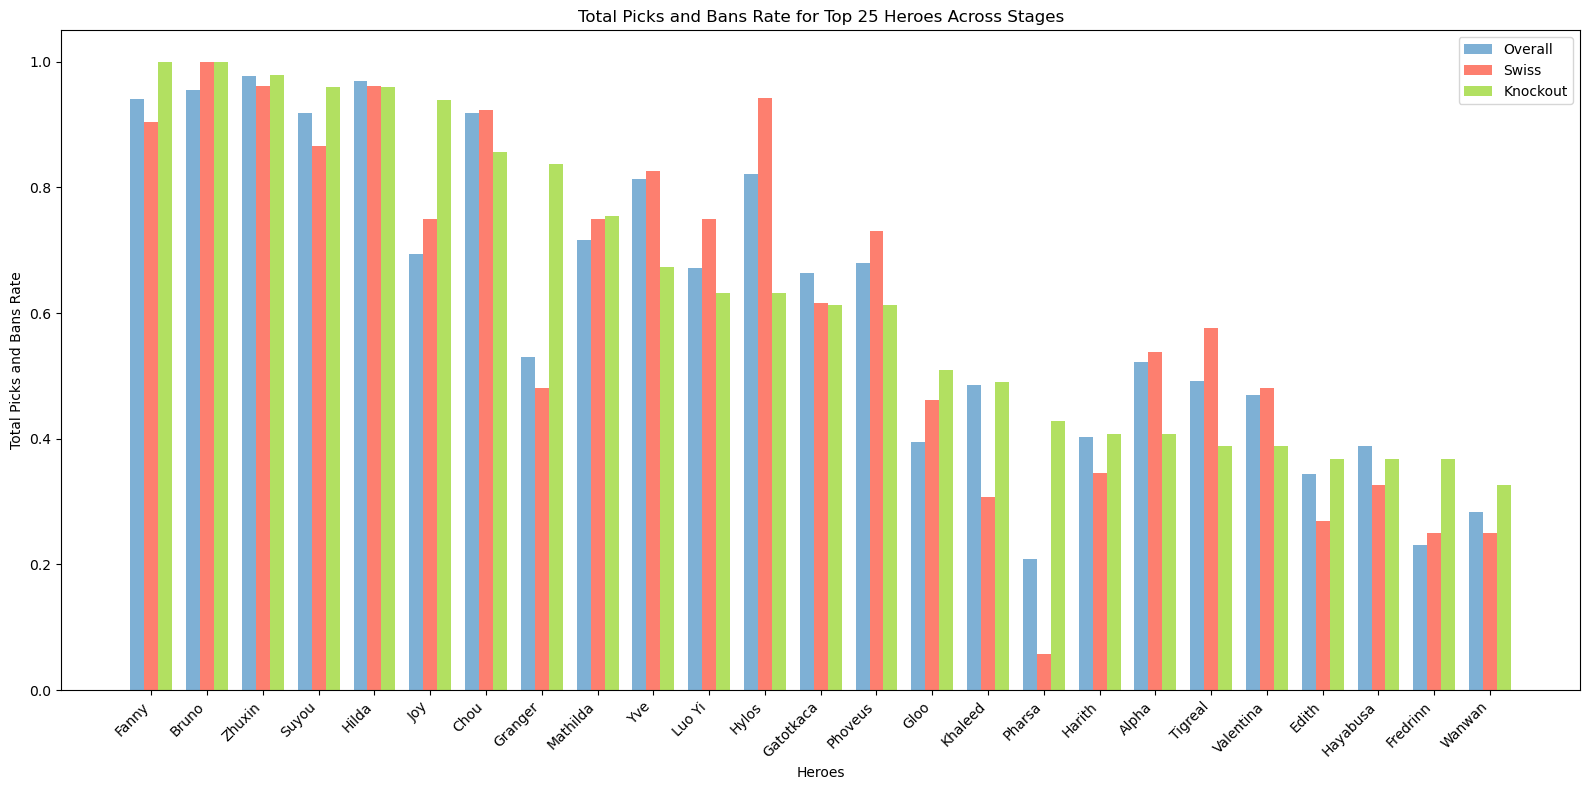

In [72]:
# Plot Total Picks and Bans Rate
plot_total_picks_and_bans(overall_filtered, swiss_filtered, knockout_filtered)

Base on the above plot, we can see some interesting bar like stats of Joy, Granger and Pharsa from knockout stage peaking highly compare to the bars for other two. 

Also another obvious bar is the bar of Hylos from Swiss stage. Compare to it's surrounding, the bar is peaking really high.

## 3.2 Win Rate vs Pick Rate

In [73]:
# Function to plot bidirectional bar chart for a single stage
def plot_bidirectional_bar_chart(stage_df, bar1, bar2, title):
    heroes = stage_df['Hero']
    
    # Handle 0 cases by filling missing values with 0
    bar1_values = stage_df[bar1].fillna(0)
    bar2_values = stage_df[bar2].fillna(0)

    # Bar chart settings
    x = np.arange(len(heroes))
    bar_width = 0.4

    # Plot
    plt.figure(figsize=(16, 8))
    plt.bar(x, bar1_values, width=bar_width, label=bar1, color='#7eb0d5', align='center')
    plt.bar(x, -bar2_values, width=bar_width, label=bar2, color='#fd7f6f', align='center')
    plt.xticks(x, heroes, rotation=45, ha='right')
    plt.xlabel("Heroes")
    plt.ylabel("Values (Bidirectional)")
    plt.title(title)
    plt.axhline(0, color='black', linewidth=0.8)  # Reference line at 0
    plt.legend()
    plt.tight_layout()
    plt.show()

Why would I include this and how am I gonna analyse base on this?

To answer this, first we can look which heroes have pick rate around 0.2 or above and win rate around 0.6.

High Pick rate doesn't always mean it is a good hero especially when the hero has very low win rate.

On the other hand, we cannot say the hero is more powerful if it is picked only 5 or 6 matches and have very high win rate as we still can argue this might be luck.

In conclusion, the two factor are depneding on each other for analysing which hero can be meta hero and thus I had incuded this plot.

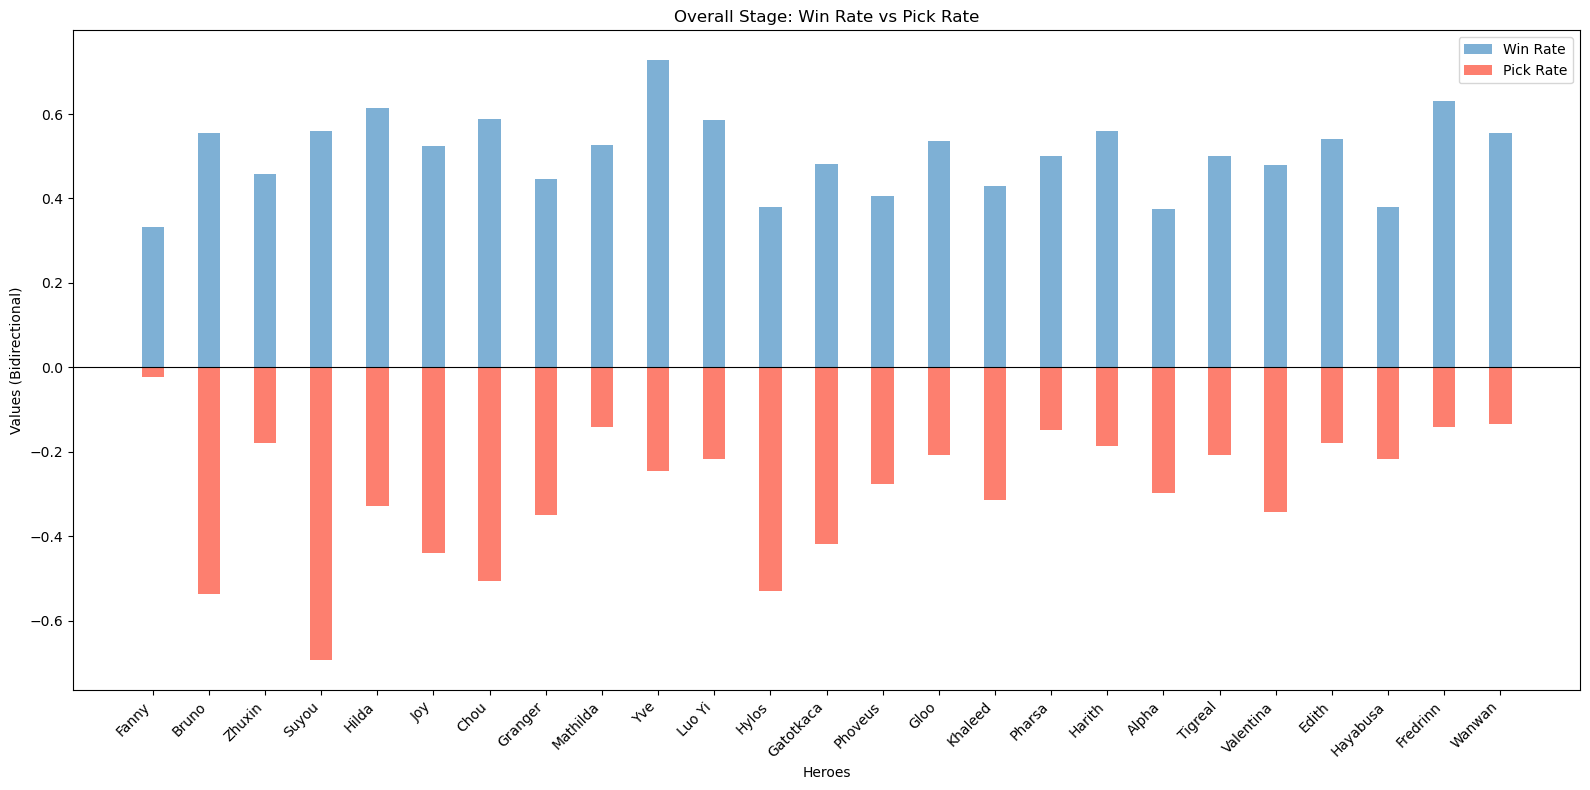

In [74]:
plot_bidirectional_bar_chart(overall_filtered, "Win Rate", "Pick Rate", "Overall Stage: Win Rate vs Pick Rate")

Base on the plot for Overall Stage, there are few heroes like Bruno, Suyou, Hilda, Chou and Yve which have a fair win rate and pick rate combination compare to other heroes.

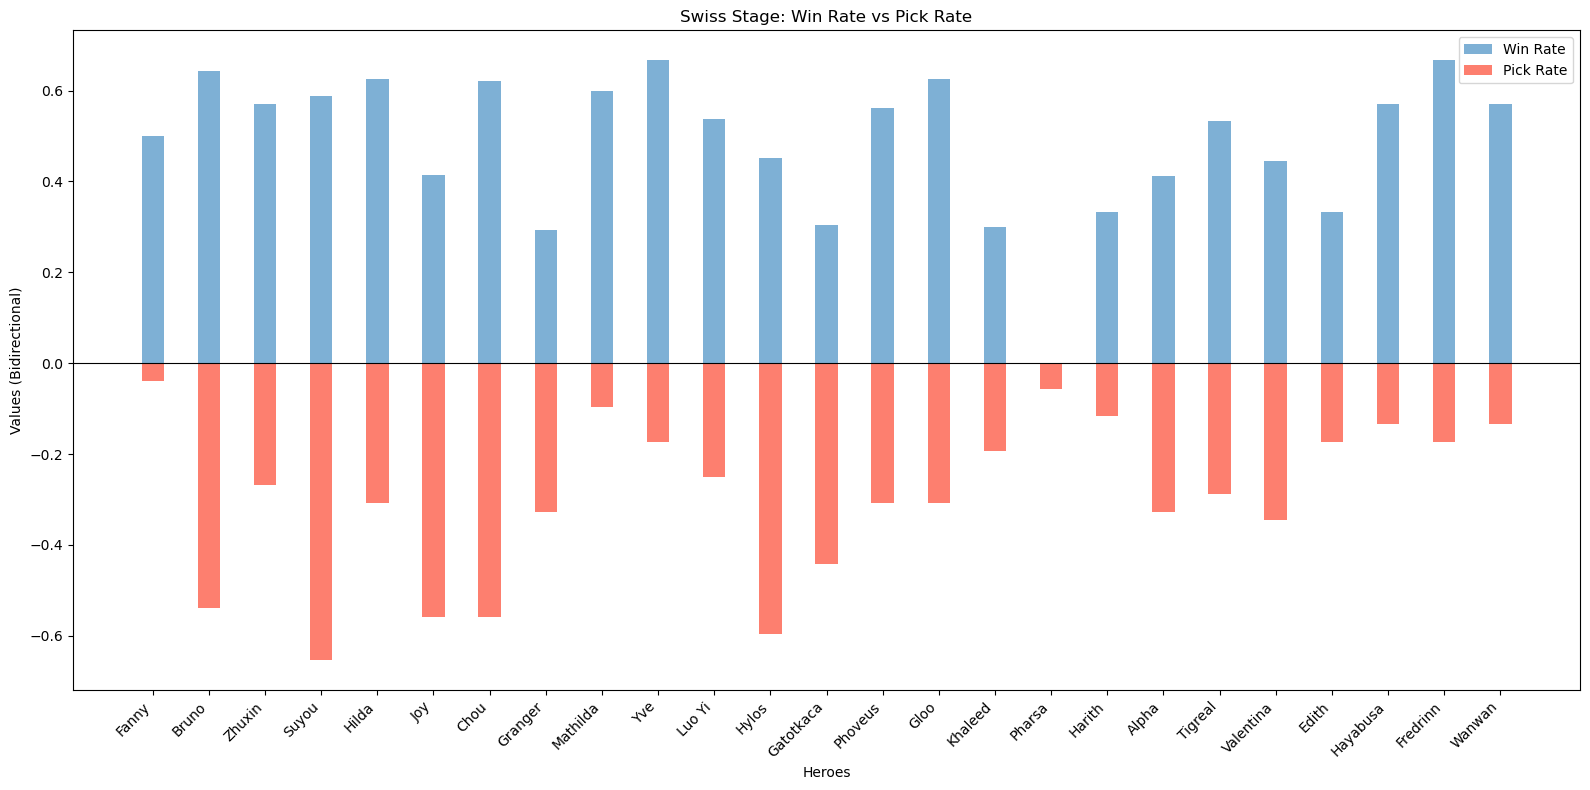

In [75]:
plot_bidirectional_bar_chart(swiss_filtered, "Win Rate", "Pick Rate", "Swiss Stage: Win Rate vs Pick Rate")

Unlike the previous plot, here we can see some Heroes has win rate above 60% and also have fair amount of pick like Bruno, Hilda, Chou, Yve and Fedrinn.

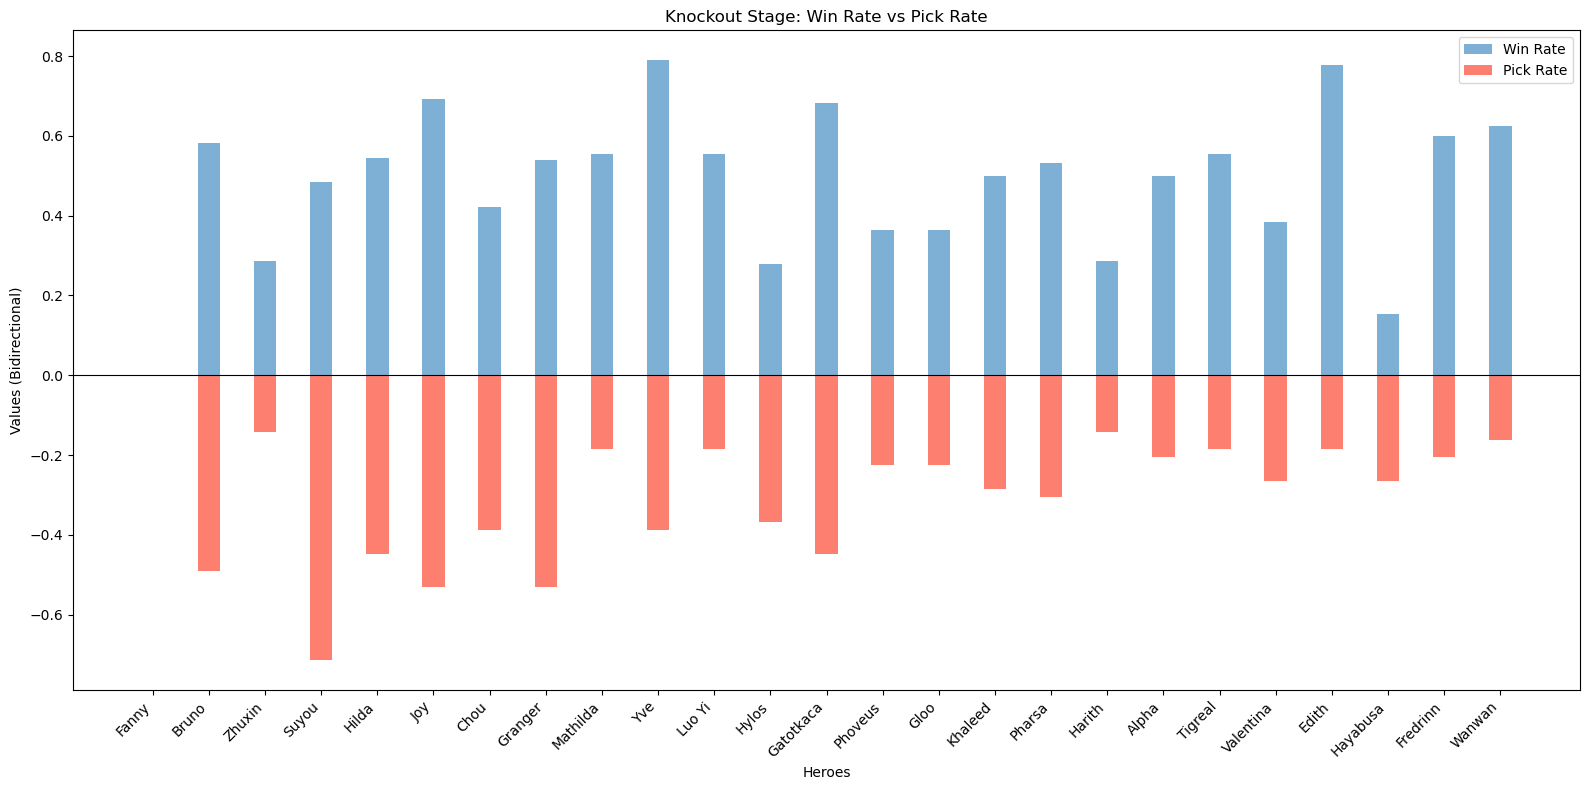

In [76]:
plot_bidirectional_bar_chart(knockout_filtered, "Win Rate", "Pick Rate", "Knockout Stage: Win Rate vs Pick Rate")

In this splot, one thing to take note is that I had drawn the plot based on the total picks and bans for Knockout stage and Fanny didn't get picked in this stage. So we can see Fanny doesn't have any bar.

Also there are two bar peaking here to 0.8 which are Yve and Edith. If compare to the game statistics, it is quite rare to see a hero with 80% win rate and got picked for a fair amount of matches.

## 3.3 Total Picks and Total Bans

In [77]:
# Function to plot Total Picks and Total Bans for a single stage
def plot_picks_vs_bans(stage_df, title):
    heroes = stage_df['Hero']
    total_picks = stage_df['Total Picks']
    total_bans = stage_df['Total Bans']

    # Bar chart settings
    x = np.arange(len(heroes))
    bar_width = 0.4

    # Plot
    plt.figure(figsize = (16, 8))
    plt.bar(x - bar_width / 2, total_picks, width=bar_width, label = 'Total Picks', color = '#7eb0d5')
    plt.bar(x + bar_width / 2, total_bans, width=bar_width, label = 'Total Bans', color = '#fd7f6f')
    plt.xticks(x, heroes, rotation = 45, ha = 'right')
    plt.xlabel("Heroes")
    plt.ylabel("Count")
    plt.title(title)
    plt.axhline(0, color = 'black', linewidth = 0.8)
    plt.legend()
    plt.tight_layout()
    plt.show()
    

It would be a bit hard to visualise only the stats of Total Picks and Bans so I had separated the two things here in case I could find some interesting things from here like odd banning pattern.

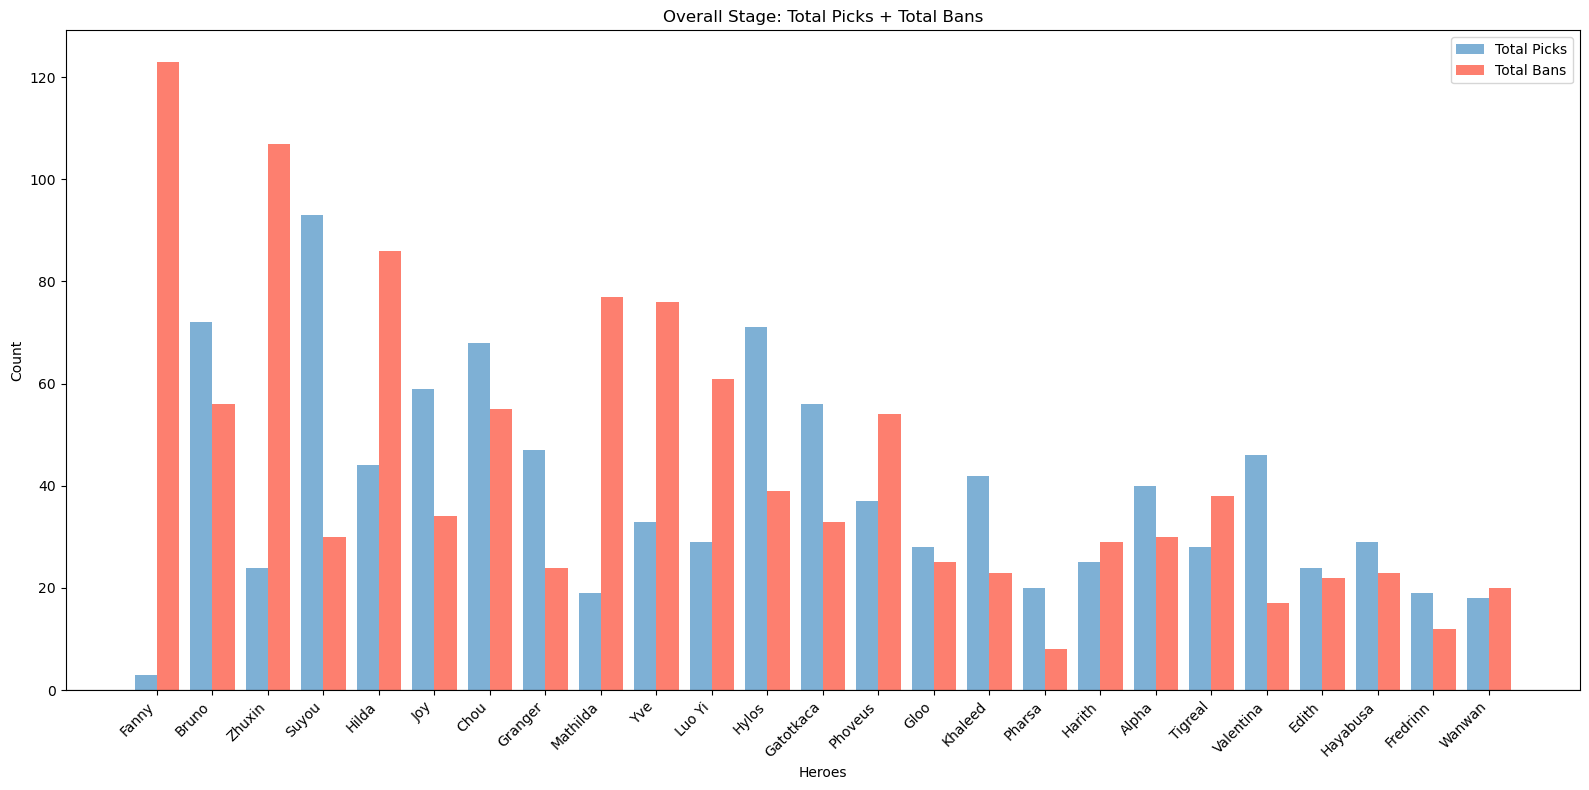

In [78]:
# Plot for Overall Stage
plot_picks_vs_bans(overall_filtered, "Overall Stage: Total Picks vs Total Bans")

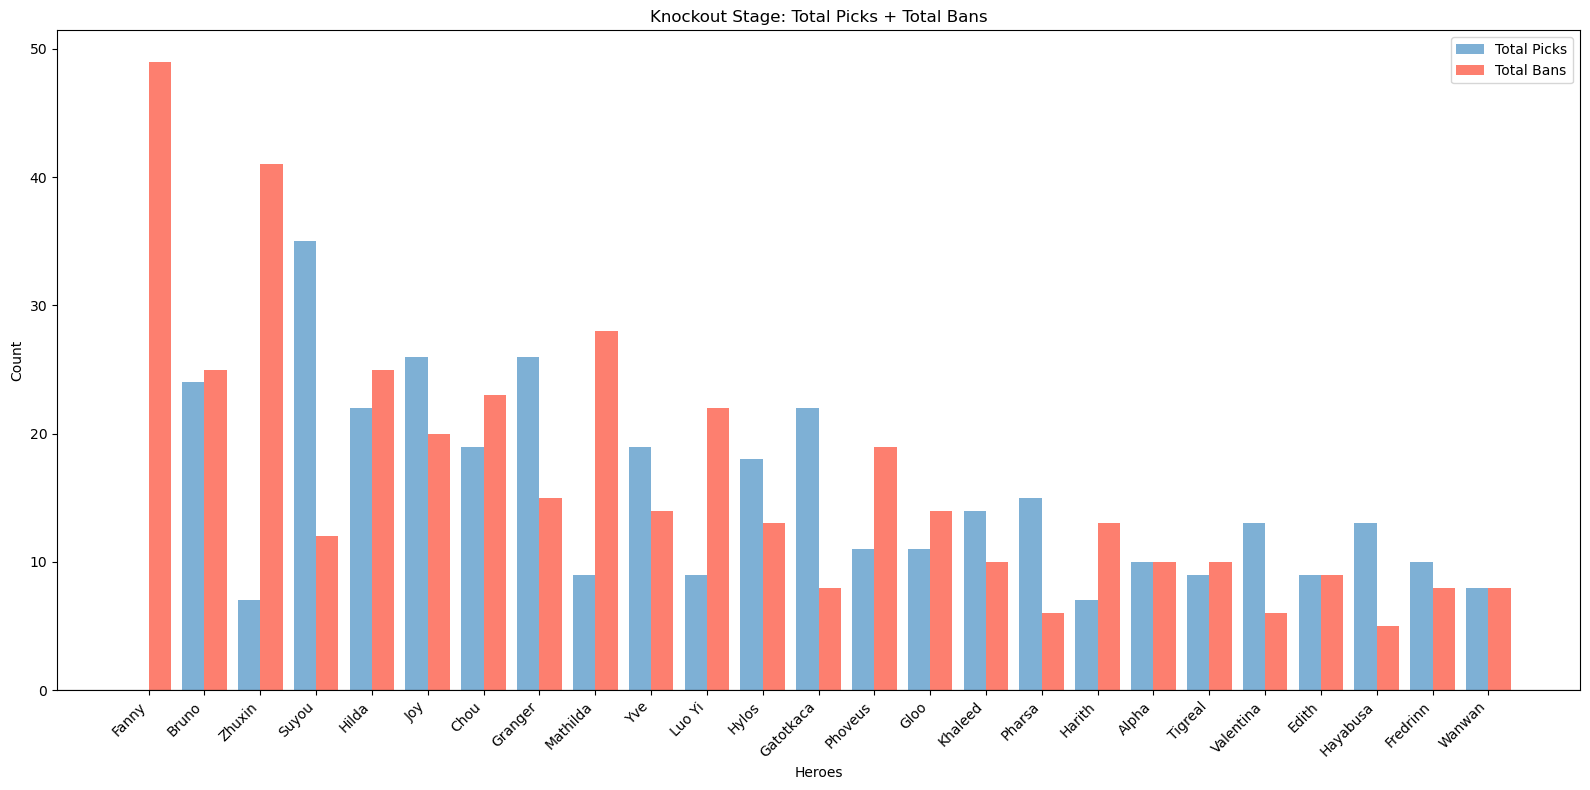

In [79]:
# Plot for Knockout Stage
plot_picks_vs_bans(knockout_filtered, "Knockout Stage: Total Picks vs Total Bans")

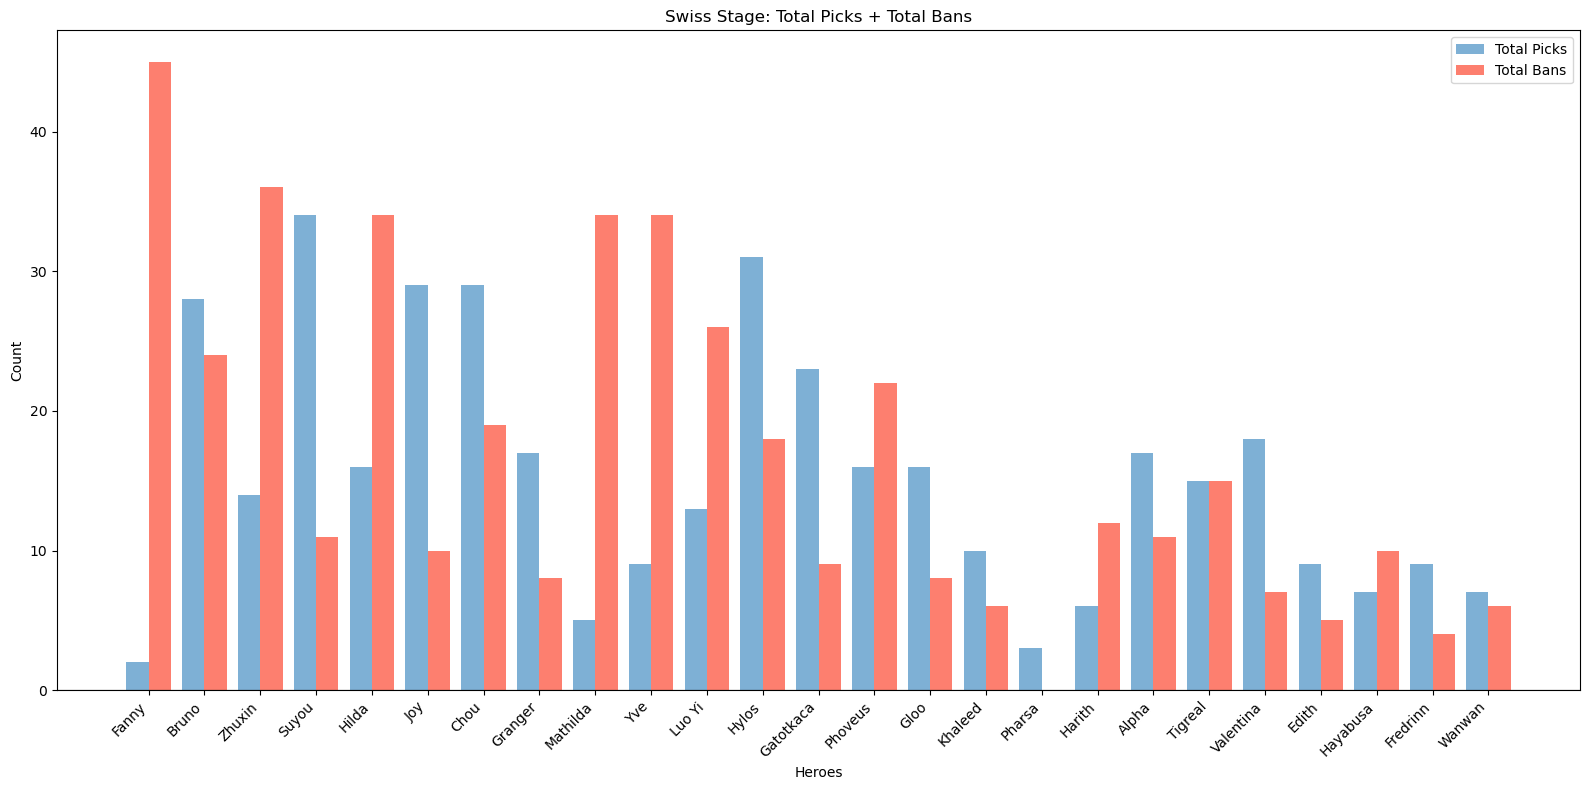

In [80]:
# Plot for Swiss Stage
plot_picks_vs_bans(swiss_filtered, "Swiss Stage: Total Picks vs Total Bans")

For these plots, I will summarise for every stages.

First thing we could clearly see is the number of bans that Fanny and Zhuxin got throughout the tournament follwed by Hilda, Malthida and Yve.

even with this fact we can see that pro team are really scare of Fanny and Zhuxin to face so we could already assume these two can be in the list of meta hero. 

## 4 Self Analysis

After reviewing all the plots from above, I have came to conclusion that these heroes are the meta hero that I think will guarantee higher chance of winning the game, if we use in our own matches.

1. Fanny: Highest Banning rate hero 
2. Zhuxin: Second highest Banning rate hero
3. Bruno: Second highest Total Picks and Bans hero, nearly 60% win rate and used in most matches if not banned
4. Hilda: Very high win rate hero with high Total Picks and Bans Rate
5. Suyou: Most Picked hero across all 3 stages with fair Win Rate
6. Joy: Quite High Win Rate with high Pick Rate in Knockout Stage
7. Yve: Very High Win Rate (nearly 80%) overall with high Total Picks and Bans Rate
8. Edith: Very High Win Rate (nearly 80%) in Knockout Stage

These are the 8 heroes that I believe are the overpower hero currently but this doesn't mean there can't be any other heroes not superior than them as all the data I use are from M6 tournament only. Because of the plots, we could also see some interesting things from other heroes and they could also be potential meta heroes.

Disclaimer: The analysis about this is all my works/opinions so I might be wrong in some condition.

## 5 Conclusion

In conclusion for my project, although most of the heroes are the one I had expected from the tables, still there are some heroes that my eyes have never caught before reviewing the plot. I think this analysis was useful for me as I get a chance to see many insight about the tournament stats. If I still had a chance, I would learn more about how to scrape the data for the matches and would go for my further objectives.

## 5.1 Used Library aand Module

requests: for sending HTTP request to the website and retrieving the html content. In my project I used this library to fetch the data from Liquipedia web pages.

Beautifulsoup from bs4 module: for parsing the html content. In my project I used this library to parse the html structure of the web page after fetching with requests.

csv: to read and write the csv file after parsing. In my project I used this module to write the scrape data into csv files.

pandas: a powerful data analysis and manipulation tool in python. In my project I used this library to clean, filter and manipulate the data

matplotlib.pyplot: sub module of matplot library for creating data visualization. In my project, I used it to generate a plot like normal bar graph and bi-directional bar graph.

numpy: generate numerical array for plotting. In my project, I used that to create numerical ranges.

## 6 Used Resources and Reference

### Dataset

https://liquipedia.net/mobilelegends/M6_World_Championship/Statistics

https://liquipedia.net/mobilelegends/M6_World_Championship/Statistics/Swiss_Stage

https://liquipedia.net/mobilelegends/M6_World_Championship/Statistics/Knockout_Stage

### Data Manipulation

https://www.w3schools.com/python/pandas/default.asp

https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html

### Data Visualization

https://www.geeksforgeeks.org/bar-plot-in-matplotlib/

https://www.techsyncer.com/python-bar-plot.html

https://www.geeksforgeeks.org/plotting-back-to-back-bar-charts-matplotlib/

https://sharkcoder.com/data-visualization/mpl-bidirectional

### Color

https://wpdatatables.com/data-visualization-color-palette/